[*********************100%***********************]  1 of 1 completed


Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Test Accuracy: 0.57
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00       107
           1       0.57      1.00      0.72       139

    accuracy                           0.57       246
   macro avg       0.28      0.50      0.36       246
weighted avg       0.32      0.57      0.41       246

Sharpe Ratio: 1.12
Max Drawdown: -13.72%


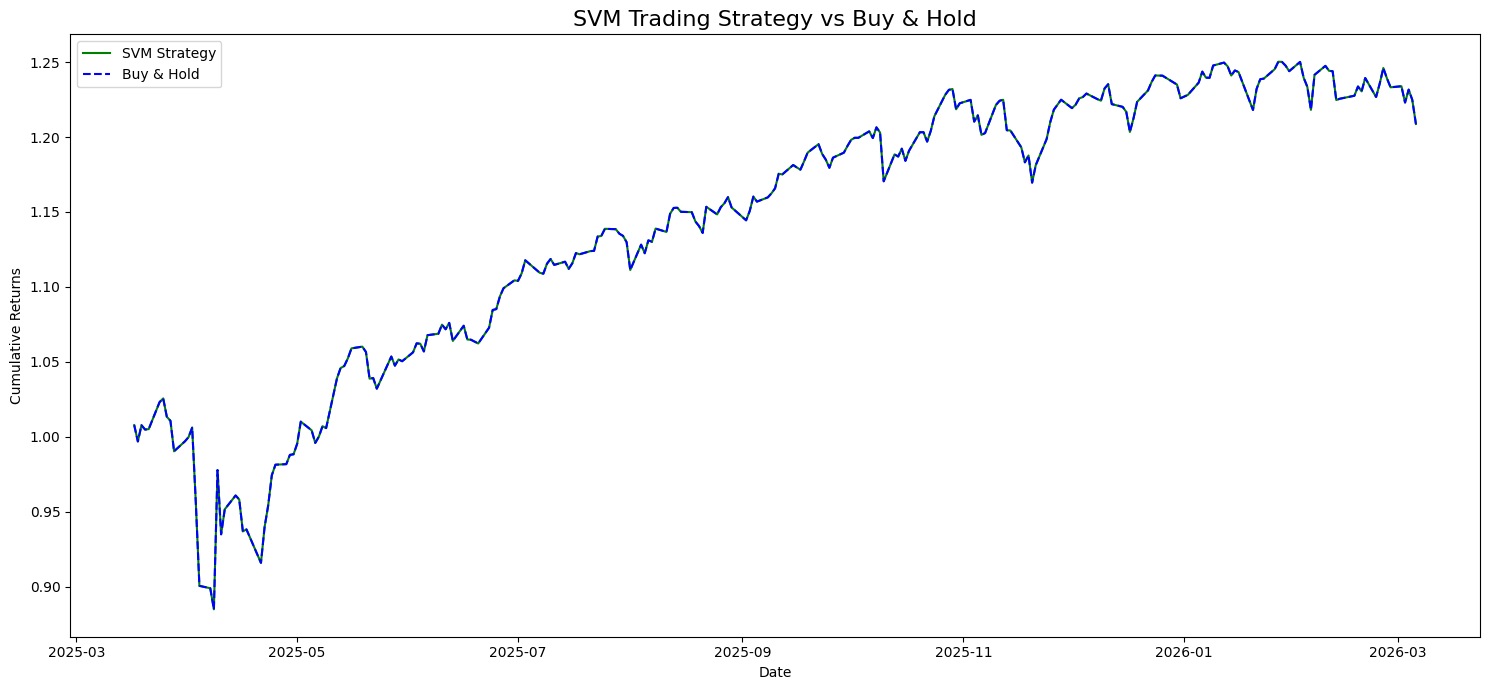

In [1]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

# --- Data ---
df = yf.download('SPY', start='2021-03-09', end='2026-03-09')
df.columns = df.columns.droplevel(1)  # flatten MultiIndex

# --- Feature Engineering ---
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = -delta.clip(upper=0).rolling(period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['Open/Close']    = df['Open'] / df['Close']
df['High/Low']      = df['High'] / df['Low']
df['SMA_10']        = df['Close'].rolling(10).mean()
df['SMA_30']        = df['Close'].rolling(30).mean()
df['RSI']           = compute_rsi(df['Close'])
df['Volatility']    = df['Close'].pct_change().rolling(10).std()
df['Volume_Change'] = df['Volume'].pct_change()
df.dropna(inplace=True)

features = ['Open/Close', 'High/Low', 'SMA_10', 'SMA_30', 'RSI', 'Volatility', 'Volume_Change']
X = df[features]
y = np.where(df['Close'].shift(-1) > df['Close'], 1, -1)

# --- Train/Test Split ---
split = int(0.8 * len(df))
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y[:split], y[split:]

# --- Scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# --- Hyperparameter Tuning ---
param_grid = {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 'auto']}
grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)
cls = grid.best_estimator_
print(f"Best Params: {grid.best_params_}")

# --- Evaluation ---
y_pred = cls.predict(X_test_scaled)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred))

# --- Backtesting ---
test_df = df.iloc[split:].copy()
test_df['Signal']           = y_pred
test_df['Returns']          = test_df['Close'].pct_change()
test_df['Strategy_Returns'] = test_df['Returns'] * test_df['Signal'].shift(1)
test_df['Cumulative_Strategy'] = (1 + test_df['Strategy_Returns']).cumprod()
test_df['Cumulative_BuyHold']  = (1 + test_df['Returns']).cumprod()

# Sharpe Ratio
sharpe = (test_df['Strategy_Returns'].mean() / test_df['Strategy_Returns'].std()) * np.sqrt(252)
print(f"Sharpe Ratio: {sharpe:.2f}")

# Max Drawdown
roll_max    = test_df['Cumulative_Strategy'].cummax()
drawdown    = (test_df['Cumulative_Strategy'] - roll_max) / roll_max
print(f"Max Drawdown: {drawdown.min():.2%}")

# --- Plot ---
plt.figure(figsize=(15, 7))
plt.plot(test_df['Cumulative_Strategy'], label='SVM Strategy', color='green')
plt.plot(test_df['Cumulative_BuyHold'],  label='Buy & Hold',   color='blue', linestyle='--')
plt.title('SVM Trading Strategy vs Buy & Hold', fontsize=16)
plt.xlabel('Date'); plt.ylabel('Cumulative Returns')
plt.legend(); plt.tight_layout(); plt.show()